# XAI Analysis (Phase 3)

Generates Grad-CAM, Saliency maps, and LIME explanations
for the trained disease detection models.

**Prerequisite**: Trained model weights in `models/` directory.

In [1]:
import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

if Path.cwd().name == 'notebooks':
    os.chdir('..')

from src.augment import get_transforms
from src.dataset import MangoLeafDataset
from src.models.disease_cnn import MangoLeafXNetSE
from src.models.xai import generate_gradcam, generate_saliency

## Load Best Model

In [2]:
device = 'cpu'
model = MangoLeafXNetSE(num_classes=8)

weight_path = Path('models/se_best.pt')
if weight_path.exists():
    checkpoint = torch.load(weight_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model from {weight_path} (val_acc={checkpoint['val_acc']:.4f})")
else:
    print("WARNING: No trained weights found. Using random weights for demo.")

model.eval()

Loaded model from models/se_best.pt (val_acc=0.9875)


MangoLeafXNetSE(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (se3): SEBlock(
    (squeeze): AdaptiveAvgPool2d(output_size=1)
    (excitation): Sequential(
      (0): Linear(in_features=128, out_features=8, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=8, out_features=128, bias=False)
      (3): Sigmoid()
    )
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kerne

## Grad-CAM Examples

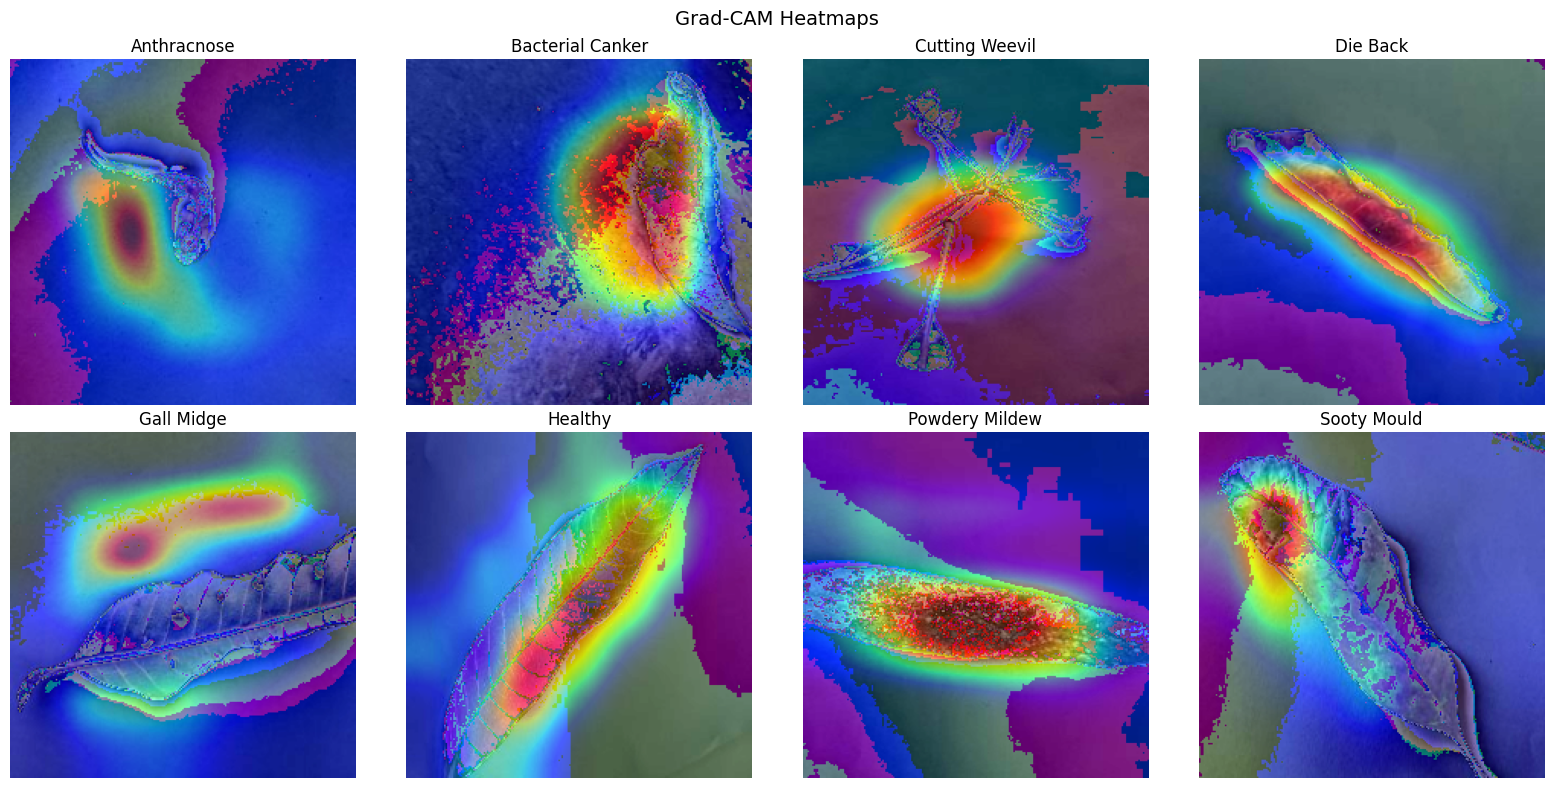

In [3]:
val_transforms = get_transforms(train=False)
dataset = MangoLeafDataset(root_dir='data/raw', transform=val_transforms)
class_names = dataset.classes

# Target layer: last conv in block6
target_layer = 'block6.0'

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    idx = i * (len(dataset) // 8)  # Sample from different classes
    image_tensor, label = dataset[idx]
    
    overlay, cam = generate_gradcam(
        model, image_tensor.unsqueeze(0), target_layer, device=device
    )
    
    ax.imshow(overlay)
    ax.set_title(f'{class_names[label]}')
    ax.axis('off')

plt.suptitle('Grad-CAM Heatmaps', fontsize=14)
plt.tight_layout()
plt.savefig('reports/figures/xai/gradcam_grid.png')

## Saliency Map Examples

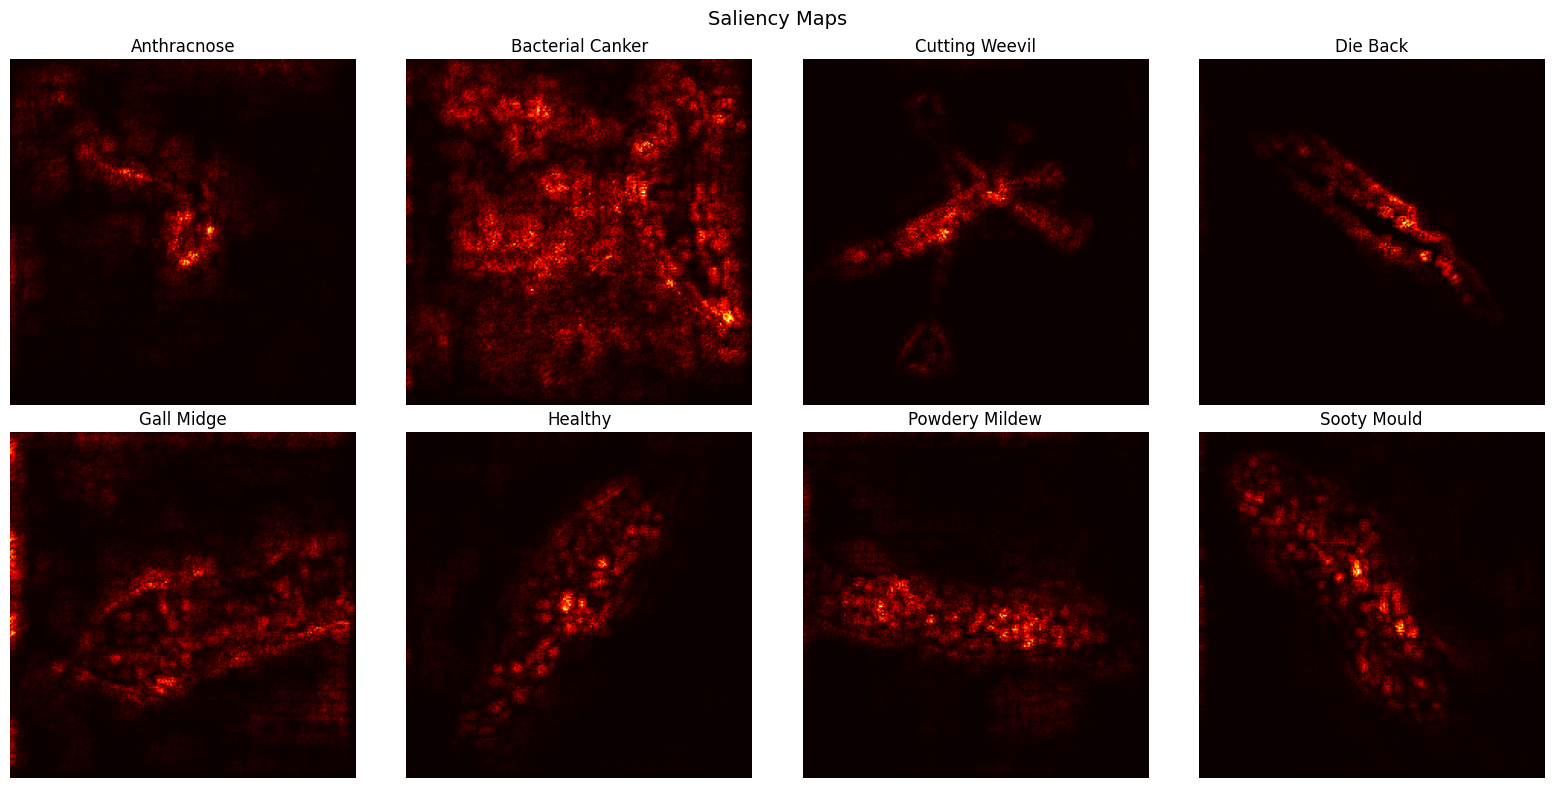

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    idx = i * (len(dataset) // 8)
    image_tensor, label = dataset[idx]
    
    saliency = generate_saliency(
        model, image_tensor.unsqueeze(0), device=device
    )
    
    ax.imshow(saliency, cmap='hot')
    ax.set_title(f'{class_names[label]}')
    ax.axis('off')

plt.suptitle('Saliency Maps', fontsize=14)
plt.tight_layout()
plt.savefig('reports/figures/xai/saliency_grid.png')

## LIME Explanations

Generate LIME explanations for 1 representative sample per class.

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

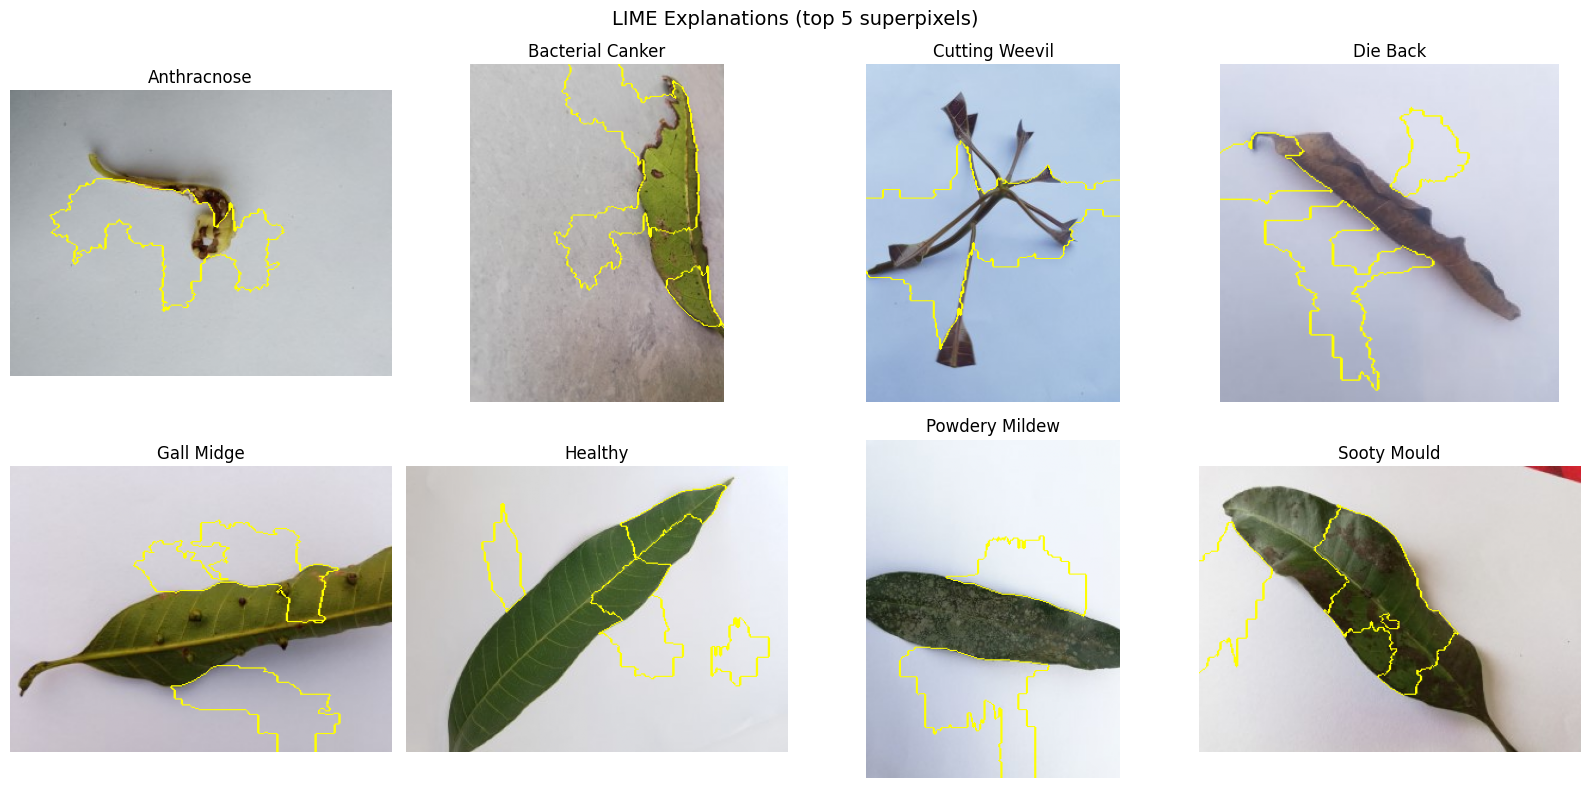

In [5]:
from src.models.xai import generate_lime
from skimage.segmentation import mark_boundaries

# Need raw (non-normalized) dataset for LIME
raw_dataset = MangoLeafDataset(root_dir='data/raw', transform=None)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    idx = i * (len(raw_dataset) // 8)
    image_np, label = raw_dataset[idx]  # Returns raw numpy (cv2 loaded)
    
    explanation, temp, mask = generate_lime(
        model, image_np, val_transforms, class_names,
        num_samples=100, device=device
    )
    
    ax.imshow(mark_boundaries(temp / 255.0, mask))
    ax.set_title(f'{class_names[label]}')
    ax.axis('off')

plt.suptitle('LIME Explanations (top 5 superpixels)', fontsize=14)
plt.tight_layout()
plt.savefig('reports/figures/xai/lime_grid.png')

## Qualitative Analysis

- Grad-CAM heatmaps should highlight **actual lesion regions** on diseased leaves.
- Healthy leaves should show diffuse, low-activation maps.
- Saliency should agree with Grad-CAM on region importance.
- LIME superpixels should overlap with lesion areas identified by Grad-CAM.